In [39]:
import pickle
import pandas as pd
import json
from tqdm import tqdm
import numpy as np
import os
import sys
from IPython.display import display, Markdown
import logging
from pythonjsonlogger.json import JsonFormatter
import matplotlib.pyplot as plt

from typing import Dict, List


In [40]:
from adr import adr
import utils
from adr_topic_mining import ADRTopicModel

In [41]:
from dotenv import load_dotenv

# Configuring OpenAI (GPT)
print(load_dotenv())

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_MODEL_NAME"] =  os.getenv('OPENAI_MODEL_NAME') # 'gpt-4o-mini'
os.environ["EMBEDDINGS_MODEL"] = os.getenv("OPENAI_EMBEDDINGS_MODEL")
# OPENAI_API_KEY = None
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# print(os.environ["OPENAI_API_KEY"])
print(os.environ["OPENAI_MODEL_NAME"])
print(os.environ["EMBEDDINGS_MODEL"])

True
gpt-4.1-mini
text-embedding-3-small


In [42]:
# This is a dictionary with all the details of the ADRs, with a hierarchical organization
# that goes from the organization to its projects and finally the ADR files inside each project
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle' 

PERFORMANCE_ADRS_JSON_DATAPATH = '../results/all_projects-qas_classification_results.json'

TOPICS_FOLDER = "performance_saved_topicmodel"
TOPICS_DATAFRAME = os.path.join(TOPICS_FOLDER, 'performance_topics_dataframe.csv')

---

In [43]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

547 projects/organizations?


In [44]:
dict_adrs

defaultdict(<function defaultdict.copy>,
            {'18F': defaultdict(dict,
                         {'aocourts-api': {'0001-cloud-dot-gov.md': <adr.adr at 0x162993cd0>,
                           '0002-graphql.md': <adr.adr at 0x1cf344690>,
                           '0003-python.md': <adr.adr at 0x1cf344d50>},
                          'identity-site': {'0001-record-architecture-decisions.md': <adr.adr at 0x1cfbf4f90>,
                           '0002-add-netlifycms.md': <adr.adr at 0x1cfbeed50>,
                           '0003-remove-basscss.md': <adr.adr at 0x1cfc369d0>}}),
             'Abelaa': defaultdict(dict,
                         {'pcmt': {'adr-001.md': <adr.adr at 0x1cfc33010>,
                           'adr-002.md': <adr.adr at 0x1cfc23990>,
                           'adr-003.md': <adr.adr at 0x1cfc235d0>,
                           'adr-004.md': <adr.adr at 0x1cfbeb990>,
                           'adr-005.md': <adr.adr at 0x1cfbeab50>,
                           

In [45]:
def count_adrs(projects):
    count_adrs = 0
    for org, project in projects:
        adrs = dict_adrs[org][project]
        count_adrs += len(adrs)
    return count_adrs


projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

print("Total number of ADRs: ", count_adrs(projects_dict['all_projects']))
print("Total number of valid ADRs: ", count_adrs(valid_projects))

organizations:   0%|          | 0/547 [00:00<?, ?it/s]

Total number of ADRs:  6061
Total number of valid ADRs:  4316


In [46]:
valid_projects

[('mozilla', 'experimenter'),
 ('guttih', 'island.is-glosur'),
 ('celestiaorg', 'optimint'),
 ('shopware', 'platform'),
 ('Internet-of-People', 'titania-os'),
 ('perforce', 'helix-authentication-service'),
 ('eclipse', 'ditto'),
 ('LBHackney-IT', 'Data-Platform-Playbook'),
 ('ministryofjustice', 'cloud-platform'),
 ('ec-europa', 'europa-component-library'),
 ('oasisprotocol', 'oasis-core'),
 ('avniproject', 'openchs-adr'),
 ('anton-liauchuk', 'educational-platform'),
 ('alphagov', 'publisher'),
 ('Informatievlaanderen', 'publicservice-registry'),
 ('alphagov', 'paas-team-manual'),
 ('pulibrary', 'figgy'),
 ('jmoratilla', 'devops-challenge'),
 ('alphagov', 'email-alert-api'),
 ('pace-neutrons', 'Horace'),
 ('jdanil', 'skunkworks'),
 ('SmartBear', 'git-en-boite'),
 ('linagora', 'linshare-mobile-android-app'),
 ('mozilla', 'uniffi-rs'),
 ('tddbin', 'katas'),
 ('alphagov', 'content-publisher'),
 ('liatrio', 'backstage-internal'),
 ('kartevonmorgen', 'rfcs'),
 ('lcarsde', 'lcarsde'),
 ('cos

In [47]:
# Read all ADRs that underwent QA classification
with open(PERFORMANCE_ADRS_JSON_DATAPATH) as f:
    classified_adrs = json.load(f)
    print("Classified ADRs:", len(classified_adrs))

# Select only those related to Performance
performance_adrs_metadata = []
for classification_record in classified_adrs:
    if classification_record['primary_category'] == 'Performance':
        metadata = classification_record['metadata']
        performance_adrs_metadata.append(tuple(list(metadata.values())))
percentage = 100 * len(performance_adrs_metadata) / len(classified_adrs)
print(len(performance_adrs_metadata), "ADRs classified as Performance", percentage, "%")

Classified ADRs: 4316
313 ADRs classified as Performance 7.2520852641334566 %


In [48]:
performance_adrs_metadata

[('KonduitAI', 'konduit-serving', '0010-Async_Pipelines.md'),
 ('molgenis', 'molgenis-r-armadillo', '0006-file-format.md'),
 ('jdanil', 'skunkworks', 'fonts.md'),
 ('influx6-prive', 'cdh-adrs', '0012-feed-parsing-dependencies.md'),
 ('edgexfoundry', 'edgex-docs', '0012-DeviceService-Filters.md'),
 ('ministryofjustice', 'opg-lpa', '0004-implement-load-testing.md'),
 ('ministryofjustice', 'opg-lpa', '0007-performance-data-platform.md'),
 ('Alfresco', 'alfresco-anaxes-shipyard', '0003-benchmark-framework-APS.md'),
 ('Datatamer',
  'tamr-client',
  '0010-confirm-performance-issues-before-optimizing.md'),
 ('guttih', 'island.is-glosur', '0003-css.md'),
 ('ministryofjustice',
  'opg-use-an-lpa',
  '0002-persistent-storage-uses-dynamodb.md'),
 ('ministryofjustice', 'opg-use-an-lpa', '0004-no-cdn-required.md'),
 ('bbc', 'digital-paper-edit-client', '2019-05-20-previewing-papercuts.md'),
 ('bbc', 'digital-paper-edit-client', '2019-05-22-exporting-video-preview.md'),
 ('openmrs', 'openmrs-rfc-fr

In [49]:
def get_text_column(df_texts,column='original_text'):
    tt = df_texts[column]
    if isinstance(tt.values[0],str):
        return tt.values.tolist()
    tt = [' '.join(x) for x in tt]
    return tt

def get_adr_texts(adrs_dict):
    """
    Get the text of the ADRs
    :param adrs_dict: dictionary with the ADRs
    :return: list of strings with the text of the ADRs
    """
    texts = []
    for org in adrs_dict.keys():
        for proj in adrs_dict[org].keys():
            adrs = list(adrs_dict[org][proj].values())
            texts.extend(adrs)
    return texts

docs = utils.get_documents(valid_projects, dict_adrs, verbose=False, field='both') # field='content')
print("Number of documents (cleaned ADRs): ", len(docs))

Number of documents (cleaned ADRs):  4316


In [50]:
docs

{('mozilla',
  'experimenter',
  '0001-build-nimbus-console-in-experimenter.md'): "build nimbus console as part of the experimenter code base Status: decided Deciders: Kate Hudson Date: 2020-08-31 Experimenter is a web application developed solely for the purpose of managing product experiments at Mozilla.  It was originally designed to manage the Shield experimentation workflow, and has expanded to include a comprehensive workflow for managing Normandy experiments.  Project Nimbus is being developed with very different core assumptions than the previous experimentation platforms, and it is unclear whether building on top of the existing Experimenter infrastructure or creating a new purpose specific application will best suit the project's needs. Meeting Project Nimbus' needs in a rapid, continuous fashion with minimal downtime the impact to (a) near-term goals of launching our first real set of feature experiments (b) mid-term goals of deprecating and replacing existing experimentatio

In [51]:
performance_docs = {k:v for k,v in docs.items() if k in performance_adrs_metadata}

In [78]:
# Flatten dict keys and values
rows = [
    (org, project, adr_key, text)
    for (org, project, adr_key), text in performance_docs.items()
]

df = pd.DataFrame(rows, columns=['organization', 'project', 'adr_id', 'text'])
df.to_csv('performance_docs_flat.csv', index=False)

print("Saved", len(df), "rows to performance_docs_flat.csv")

Saved 313 rows to performance_docs_flat.csv


In [52]:
adr_topic_model = ADRTopicModel()

## Topic Model for Performance-Related ADRs

In [53]:
PERFORMANCE_PROMPT = """"
You are an assistant for a software developer that needs to analyze documents containing architectural design decisions.
In this context, I have a software performance-related topic that affects the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the above information, can you assign a descriptive label, probably about performance, of at most 7 words to the topic?
Answer:
"""

In [54]:
# adr_topic_model.prepare_corpus(performance_docs)
# adr_topic_model.build(use_openai=True, prompt=PERFORMANCE_PROMPT)

# In this case, an existing topic model is preloaded (alternatively, it can be built from scratch)
adr_topic_model.load(TOPICS_FOLDER)

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,120,-1_geoprocessing_performance_service_queue,Performance Optimization in Data Filtering and...,"[geoprocessing, performance, service, queue, s...",[Performance Optimization in Data Filtering an...,NaN
1,0,51,0_webpack_components_react_component,Optimizing JavaScript and CSS Performance in W...,"[webpack, components, react, component, builds...",[Optimizing JavaScript and CSS Performance in ...,NaN
2,1,33,1_blobstore_storage_storing_cassandra,Optimizing BlobStore and Database Performance ...,"[blobstore, storage, storing, cassandra, store...",[Optimizing BlobStore and Database Performance...,NaN
3,2,32,2_elasticsearch_indexing_indexed_index,Search Performance Optimization and Index Upda...,"[elasticsearch, indexing, indexed, index, rank...",[Search Performance Optimization and Index Upd...,NaN
4,3,24,3_statesync_sync_tendermint_snapshots,Efficient Node State Sync and Snapshot Perform...,"[statesync, sync, tendermint, snapshots, snaps...",[Efficient Node State Sync and Snapshot Perfor...,NaN
5,4,17,4_reports_database_apis_reporting,Database Query Performance and Reporting Optim...,"[reports, database, apis, reporting, dashboard...",[Database Query Performance and Reporting Opti...,NaN
6,5,15,5_cosmos_proto_cosmos_protocodec_encoded,Cosmos SDK encoding and state performance opti...,"[cosmos_proto, cosmos, protocodec, encoded, pr...",[Cosmos SDK encoding and state performance opt...,NaN
7,6,11,6_apis_wsgi_benchmark_loadtest,API and Server Performance Testing and Benchma...,"[apis, wsgi, benchmark, loadtest, frameworks, ...",[API and Server Performance Testing and Benchm...,NaN
8,7,10,7_jmap_messagepreviewstore_messages_getmessages,JMAP message property retrieval performance op...,"[jmap, messagepreviewstore, messages, getmessa...",[JMAP message property retrieval performance o...,NaN


In [55]:
# adr_topic_model.persist(TOPICS_FOLDER)

In [56]:
# List all topic labels (KeyBERT representation)
adr_topic_model.get_topic_labels()

['-1_geoprocessing_performance_service_queue',
 '0_webpack_components_react_component',
 '1_blobstore_storage_storing_cassandra',
 '2_elasticsearch_indexing_indexed_index',
 '3_statesync_sync_tendermint_snapshots',
 '4_reports_database_apis_reporting',
 '5_cosmos_proto_cosmos_protocodec_encoded',
 '6_apis_wsgi_benchmark_loadtest',
 '7_jmap_messagepreviewstore_messages_getmessages']

In [57]:
# List all topic lables (OpenAI representation)
adr_topic_model.get_topic_labels(representation='OpenAI')

['Performance Optimization in Data Filtering and Processing',
 'Optimizing JavaScript and CSS Performance in Web Applications',
 'Optimizing BlobStore and Database Performance Plans',
 'Search Performance Optimization and Index Update Strategies',
 'Efficient Node State Sync and Snapshot Performance',
 'Database Query Performance and Reporting Optimization',
 'Cosmos SDK encoding and state performance optimizations',
 'API and Server Performance Testing and Benchmarking',
 'JMAP message property retrieval performance optimization']

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


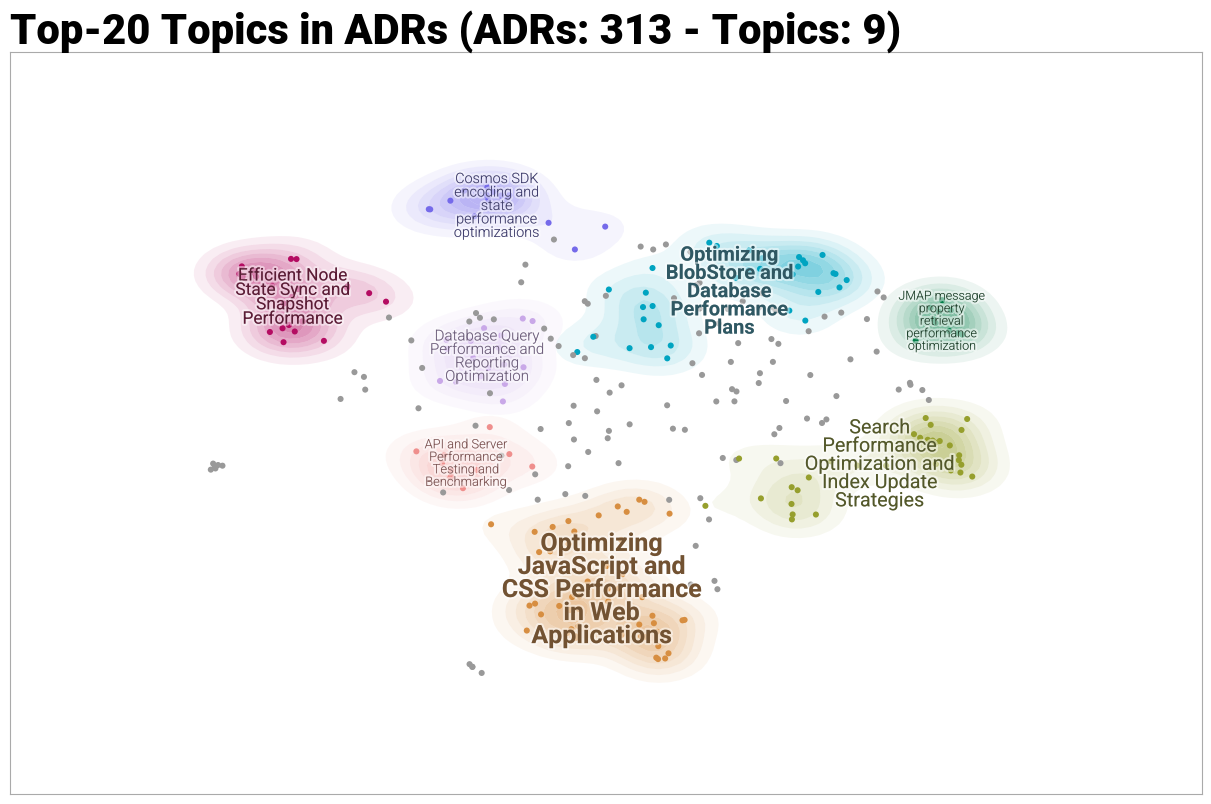

In [58]:
adr_topic_model.show_topic_map()

In [59]:
# Example of predicting the main topic for a 1 single ADR
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 

adr_topic_model.predict(new_doc, multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-23 23:55:36,073 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


{'text': 'Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that\'s already been done making these easy to use and secure by default. There\'s a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.',
 'topics': [5],
 'keywords': [['cosm

In [60]:
# Get a set of ADRs from a (random) org/project pair
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

In [61]:
# Example of predicting the main topic for a group of ADRs (batch)
adr_topic_model.predict_batch(adrs_to_classify, organization='LBHackney-IT', project='remultiform', multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-23 23:55:36,371 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
Inferring topics for ADRs: 10it [00:00, 13054.17it/s]


[{'text': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
  'topics': [4],
  'keywords': [['reports',
    'database',
    'apis',
    'reporting',
    'dashboard',
    'materialized',
    'graphql',
    'data',
    'api',
    'queries']],
  'keybert_representation': ['3_statesync_sync_tendermint_snapshots'],
  'openai_representation': ['Efficient Node State Sync and Snapshot Performance'],
  'probabilities': [0.49662506580352783],
  'metadata': {'organization': 'LBHackney-IT',
   'project': 'remultiform',
   'adr_key': '0001-record-ar

---

## Additional visualization of BERTopic

In [62]:
topic_model = adr_topic_model.topic_model

In [63]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy to check for spurious topics (i.e., irrelevant contents)

In [64]:
# For ADR contents (only)
# topics_to_merge = [-1, 3, 22, 23] # Spurious topics (e.g., ADR template) 
# topic_model.merge_topics(corpus, topics_to_merge) # It can take a while

### Visualization of Documents

In [65]:
n_adrs = len(adr_topic_model.corpus)
n_topics = len(adr_topic_model.topics_df)
print("Number of ADRs:", n_adrs)
print("Number of topics:", n_topics)

Number of ADRs: 313
Number of topics: 9


In [66]:
first_20_topics = adr_topic_model.get_topk_topics(8)
first_20_topics

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,120,-1_geoprocessing_performance_service_queue,Performance Optimization in Data Filtering and...,"[geoprocessing, performance, service, queue, s...",[Performance Optimization in Data Filtering an...,NaN
1,0,51,0_webpack_components_react_component,Optimizing JavaScript and CSS Performance in W...,"[webpack, components, react, component, builds...",[Optimizing JavaScript and CSS Performance in ...,NaN
2,1,33,1_blobstore_storage_storing_cassandra,Optimizing BlobStore and Database Performance ...,"[blobstore, storage, storing, cassandra, store...",[Optimizing BlobStore and Database Performance...,NaN
3,2,32,2_elasticsearch_indexing_indexed_index,Search Performance Optimization and Index Upda...,"[elasticsearch, indexing, indexed, index, rank...",[Search Performance Optimization and Index Upd...,NaN
4,3,24,3_statesync_sync_tendermint_snapshots,Efficient Node State Sync and Snapshot Perform...,"[statesync, sync, tendermint, snapshots, snaps...",[Efficient Node State Sync and Snapshot Perfor...,NaN
5,4,17,4_reports_database_apis_reporting,Database Query Performance and Reporting Optim...,"[reports, database, apis, reporting, dashboard...",[Database Query Performance and Reporting Opti...,NaN
6,5,15,5_cosmos_proto_cosmos_protocodec_encoded,Cosmos SDK encoding and state performance opti...,"[cosmos_proto, cosmos, protocodec, encoded, pr...",[Cosmos SDK encoding and state performance opt...,NaN
7,6,11,6_apis_wsgi_benchmark_loadtest,API and Server Performance Testing and Benchma...,"[apis, wsgi, benchmark, loadtest, frameworks, ...",[API and Server Performance Testing and Benchm...,NaN


In [67]:
first_20_topics

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,120,-1_geoprocessing_performance_service_queue,Performance Optimization in Data Filtering and...,"[geoprocessing, performance, service, queue, s...",[Performance Optimization in Data Filtering an...,NaN
1,0,51,0_webpack_components_react_component,Optimizing JavaScript and CSS Performance in W...,"[webpack, components, react, component, builds...",[Optimizing JavaScript and CSS Performance in ...,NaN
2,1,33,1_blobstore_storage_storing_cassandra,Optimizing BlobStore and Database Performance ...,"[blobstore, storage, storing, cassandra, store...",[Optimizing BlobStore and Database Performance...,NaN
3,2,32,2_elasticsearch_indexing_indexed_index,Search Performance Optimization and Index Upda...,"[elasticsearch, indexing, indexed, index, rank...",[Search Performance Optimization and Index Upd...,NaN
4,3,24,3_statesync_sync_tendermint_snapshots,Efficient Node State Sync and Snapshot Perform...,"[statesync, sync, tendermint, snapshots, snaps...",[Efficient Node State Sync and Snapshot Perfor...,NaN
5,4,17,4_reports_database_apis_reporting,Database Query Performance and Reporting Optim...,"[reports, database, apis, reporting, dashboard...",[Database Query Performance and Reporting Opti...,NaN
6,5,15,5_cosmos_proto_cosmos_protocodec_encoded,Cosmos SDK encoding and state performance opti...,"[cosmos_proto, cosmos, protocodec, encoded, pr...",[Cosmos SDK encoding and state performance opt...,NaN
7,6,11,6_apis_wsgi_benchmark_loadtest,API and Server Performance Testing and Benchma...,"[apis, wsgi, benchmark, loadtest, frameworks, ...",[API and Server Performance Testing and Benchm...,NaN


In [68]:
# embeddings = adr_topic_model.embedding_model.encode(adr_topic_model.corpus, show_progress_bar=True)

# It works only if the number of topics is not too high
# topic_model.visualize_document_datamap(docs=adr_topic_model.corpus, embeddings=embeddings, topics=first_20_topics['Topic'].tolist())
#                                       interactive=True, custom_labels=False, topics=first_20_topics,
#                                        topic_prefix=True, enable_search=True, title="Top-20 Topics in ADRs") 

### Visualization of Topics

In [69]:
fig = topic_model.visualize_topics(custom_labels=True, title="Topic Mapping (Top 20 Topics)", top_n_topics=20) 
fig

In [70]:
topic_model.visualize_barchart(custom_labels=False, top_n_topics=20, title="Top 20 Topics in ADRs") # It can be saved as a PNG file

In [71]:
topic_model.visualize_heatmap() # Topic similarity

### Hierarchies

In [72]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy

### World Cloud

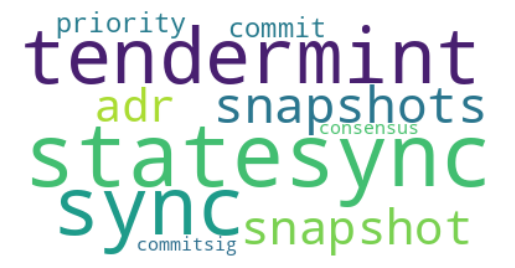

In [73]:
# Show wordcloud
adr_topic_model.show_wordcloud(topic_id=3)

In [74]:
new_doc = list(performance_docs.values())[5]
new_doc

"h0 Currently, our main storefront scripts (inline scripts as well as all.js) are located at the bottom of the page near the body end tag. The async attribute is used for the all.js but it isn't really suitable because our own JavaScript plugins depend on DOM elements in order to be initialized, and we have to wait for the document to be finished anyway. Additionally, the DOMContentLoaded is not compatible with async scripts because they might run before this particular event. That's why document.readystatechange --> complete is being used at the moment. This has the downside, that none of our JavaScript plugins initializes before the entire document is fully loaded including all resources like images. In order to improve the script loading all default <script> tags are moved to the <head> and get a defer attribute in favor of async. To initialize the JavaScript plugins, the DOMContentLoaded is being used instead of document.readystatechange --> complete. This ensures that the JavaScri

In [75]:
# New documents to predict
# new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 

result = adr_topic_model.predict(new_doc, as_dict=False)

color_name_markdown = '<span style="color: orange;">' + new_doc + '</span>'
display(Markdown(color_name_markdown))

print(f"Topics: {result.topics}") # e.g., [0, 1]
print(f"Probabilities: {result.probabilities}") # e.g., [0.9, 0.8]
print("-----")
threshold = 0.1
labels = topic_model.get_topic_info()['CustomName'].tolist()
for topic, prob in zip(result.topics, result.probabilities):
    if prob > threshold:
        print(f"Topic {topic}: {result.keybert_representation}")
        print(f"Label: {result.openai_representation}")
        print(f"{result.keywords}")
    print("-----")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-23 23:55:37,464 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


<span style="color: orange;">h0 Currently, our main storefront scripts (inline scripts as well as all.js) are located at the bottom of the page near the body end tag. The async attribute is used for the all.js but it isn't really suitable because our own JavaScript plugins depend on DOM elements in order to be initialized, and we have to wait for the document to be finished anyway. Additionally, the DOMContentLoaded is not compatible with async scripts because they might run before this particular event. That's why document.readystatechange --> complete is being used at the moment. This has the downside, that none of our JavaScript plugins initializes before the entire document is fully loaded including all resources like images. In order to improve the script loading all default <script> tags are moved to the <head> and get a defer attribute in favor of async. To initialize the JavaScript plugins, the DOMContentLoaded is being used instead of document.readystatechange --> complete. This ensures that the JavaScript plugins initialization must only wait for the document itself but not for additional resources like images. This change allows the browser to download/fetch the scripts right away when the <head> is parsed instead of when almost the entire document is already parsed. Because of defer the script execution will wait until the document is parsed (Just right before the DOMContentLoaded event). defer also ensures that the different <script>'s are executed in the order in which they are declared. All app/plugin script tags which extended one of the base_body_script child blocks must be moved to Resources/views/storefront/layout/meta.html.twig</span>

Topics: [0]
Probabilities: [0.5857616662979126]
-----
Topic 0: ['-1_geoprocessing_performance_service_queue']
Label: ['Performance Optimization in Data Filtering and Processing']
[['webpack', 'components', 'react', 'component', 'builds', 'styles', 'typescript', 'build', 'dependencies', 'performance']]
-----


---
### Metrics

In [76]:
# Topic coherence quantifies the semantic similarity among words within a topic. 
# A high coherence score indicates that the words in a topic are closely related and likely to appear together in documents
# Coherence scores typically range from 0 to 1, with 1 representing perfect coherence and 0 representing no coherence. 
# For instance, a good coherence score might be around 0.5 or higher

# Topic diversity measures how distinct or unique different topics are from each other. 
# A high diversity score suggests that the topics capture a wide range of different aspects of the corpus.


print("Coherence=", adr_topic_model.compute_topic_coherence())
print("Diversity=", adr_topic_model.compute_topic_diversity())

Coherence= 0.32481457684706483
Diversity= 0.9903926482873852


---